In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import io
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [1]:
import os
os.makedirs("news_category_visualization", exist_ok=True)
print("Directory created: news_category_visualization")

Directory created: news_category_visualization


In [5]:
CSV_PATH = "data/Sinhala-News-Category-classification/sinhala-news-categories.csv"
df = pd.read_csv(CSV_PATH)

# Normalize column names (strip whitespace)
df.columns = df.columns.str.strip()
df["comments"] = df["comments"].astype(str).str.strip()
df["labels"] = pd.to_numeric(df["labels"], errors="coerce")

print(f"Dataset loaded: {len(df)} rows, {len(df.columns)} columns")
print(df.head())

Dataset loaded: 3327 rows, 2 columns
                                            comments  labels
0  ලෝක පාපන්දු සම්මේලනයේ සභාපති සෙප් බ්ලැටර් ස්වක...       3
1  තමාට එරෙහිව ඇති දූෂණ චෝදනා පිළිබඳ ස්වාධීන පරීක...       3
2  ලෝක පාපන්දු ක්‍රීඩාවේ අනාගතයටත්, කටාර් හා රුසි...       3
3  පසුගියදා පැවති නිලවරණයෙන් පස් වන වතාවටත් තේරීප...       3
4  අන්තර්ජාතික පාපන්දු සංගමයේ නව සභාවතිවරයා ලෙස ප...       3


In [5]:
print("─" * 50)
print("DATAFRAME INFO")
print("─" * 50)
print(df.info())

print("\n─" * 50)
print("DESCRIPTIVE STATISTICS")
print("─" * 50)
print(df.describe(include="all"))

print("\n─" * 50)
print("MISSING VALUES")
print("─" * 50)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing cells: {missing.sum()}")

print("\n─" * 50)
print("DUPLICATE ROWS")
print("─" * 50)
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

──────────────────────────────────────────────────
DATAFRAME INFO
──────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 3327 entries, 0 to 3326
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   comments  3327 non-null   str  
 1   labels    3327 non-null   int64
dtypes: int64(1), str(1)
memory usage: 1.3 MB
None

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
DESCRIPTIVE STATISTICS
──────────────────────────────────────────────────
                                                 comments       labels
count                                                3327  3327.000000
unique                                               3246          NaN
top     (මෙම වීඩියෝව මෙම පිටුවෙහි සිට නැරඹීමට නොහැකි න...          NaN
freq                                                    9          NaN
mean                                                  NaN  

Label Distribution:
        Count  Percentage (%)
labels                       
0         560           16.83
1         458           13.77
2         854           25.67
3        1017           30.57
4         438           13.17


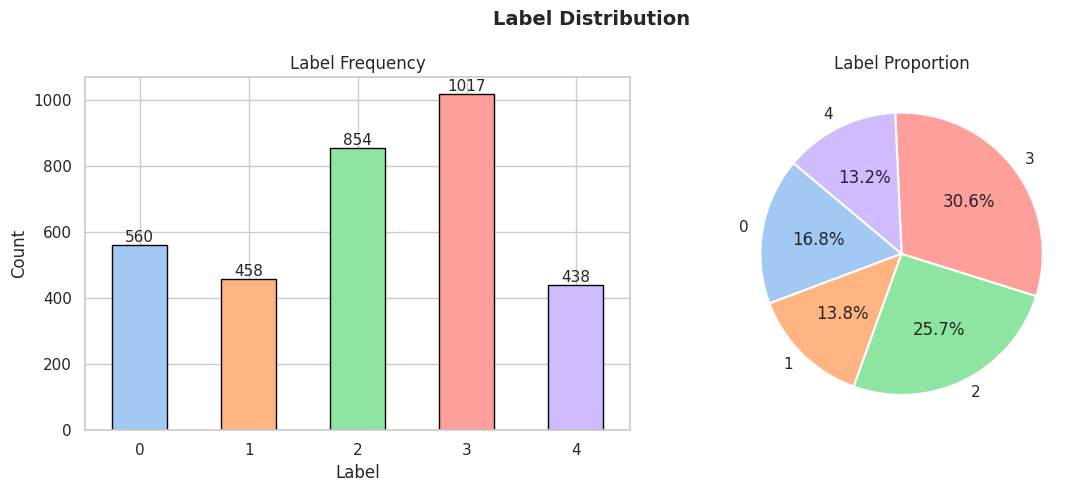

Saved: news_category_visualization/label_distribution.png


In [6]:
label_counts = df["labels"].value_counts().sort_index()
label_pct = df["labels"].value_counts(normalize=True).sort_index() * 100

label_summary = pd.DataFrame({
    "Count": label_counts,
    "Percentage (%)": label_pct.round(2)
})
print("Label Distribution:")
print(label_summary)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
label_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("pastel"), edgecolor="black")
axes[0].set_title("Label Frequency")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for bar in axes[0].patches:
    axes[0].annotate(f"{int(bar.get_height())}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=11)

# Pie chart
axes[1].pie(label_counts, labels=label_counts.index.astype(str),
            autopct="%1.1f%%", colors=sns.color_palette("pastel"),
            startangle=140, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Label Proportion")

plt.suptitle("Label Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("news_category_visualization/label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: news_category_visualization/label_distribution.png")

Text Length Stats:
       char_count  word_count  unique_chars
count     3327.00     3327.00       3327.00
mean       148.05       23.43         34.88
std        119.23       18.63         11.12
min          1.00        1.00          1.00
25%         75.00       12.00         29.00
50%        117.00       19.00         34.00
75%        179.00       28.00         40.00
max       1094.00      161.00         89.00


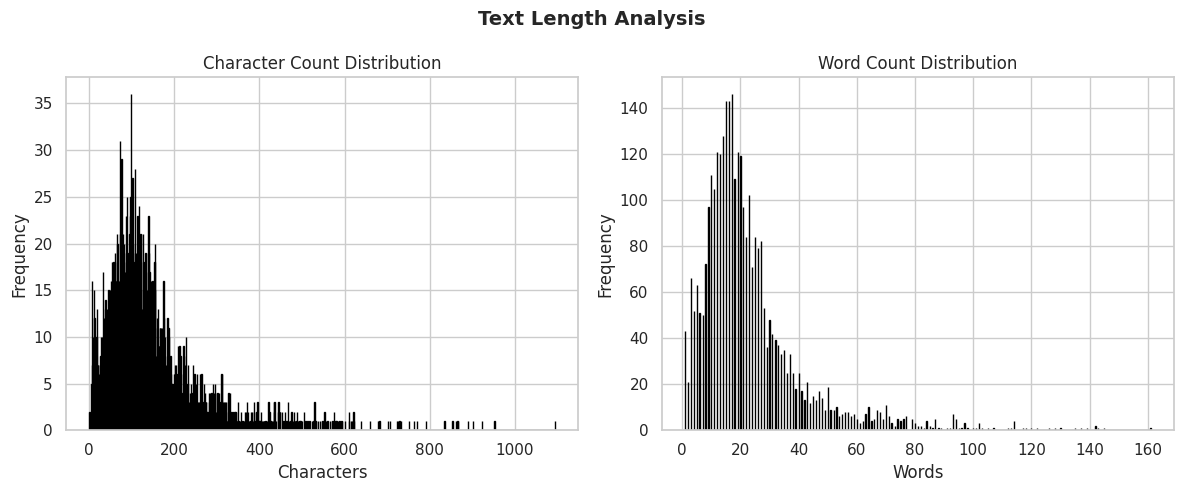

Saved: text_length_distribution.png


In [ ]:
df["char_count"] = df["comments"].str.len()
df["word_count"] = df["comments"].str.split().str.len()
df["unique_chars"] = df["comments"].apply(lambda x: len(set(x)))

print("Text Length Stats:")
print(df[["char_count", "word_count", "unique_chars"]].describe().round(2))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["char_count"], bins=max(5, len(df)//2), color="#74b9ff", edgecolor="black")
axes[0].set_title("Character Count Distribution")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["word_count"], bins=max(5, len(df)//2), color="#a29bfe", edgecolor="black")
axes[1].set_title("Word Count Distribution")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")

plt.suptitle("Text Length Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("news_category_visualization/text_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: news_category_visualization/text_length_distribution.png")

Average character count per label:
labels
0    177.7
1    179.2
2    108.3
3     91.8
4    285.5
Name: char_count, dtype: float64

Average word count per label:
labels
0    27.6
1    27.1
2    17.4
3    15.0
4    45.5
Name: word_count, dtype: float64


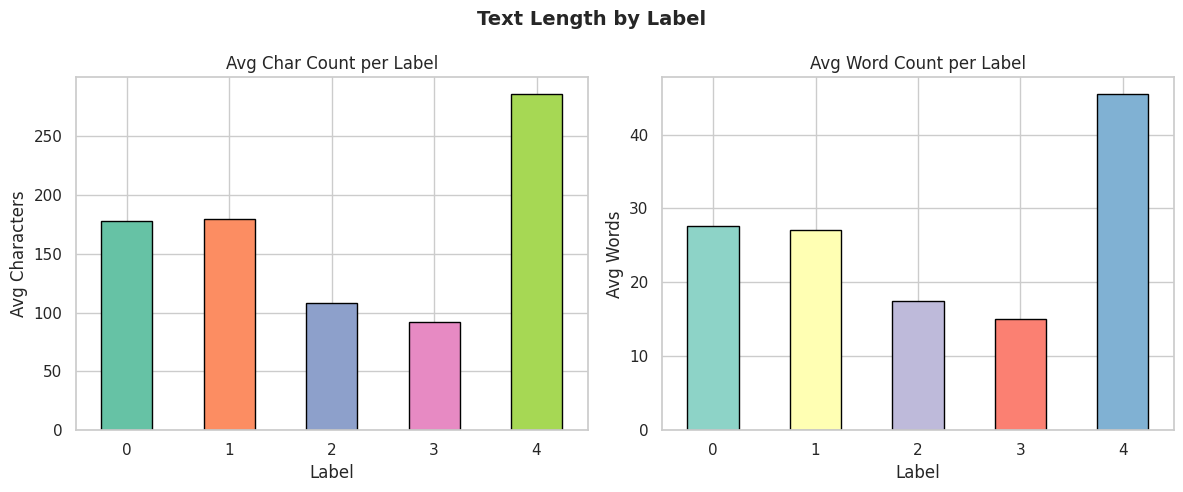

Saved: text_length_by_label.png


In [ ]:
print("Average character count per label:")
print(df.groupby("labels")["char_count"].mean().round(1))

print("\nAverage word count per label:")
print(df.groupby("labels")["word_count"].mean().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.groupby("labels")["char_count"].mean().plot(
    kind="bar", ax=axes[0], color=sns.color_palette("Set2"), edgecolor="black")
axes[0].set_title("Avg Char Count per Label")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Avg Characters")
axes[0].tick_params(axis="x", rotation=0)

df.groupby("labels")["word_count"].mean().plot(
    kind="bar", ax=axes[1], color=sns.color_palette("Set3"), edgecolor="black")
axes[1].set_title("Avg Word Count per Label")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Avg Words")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Text Length by Label", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("news_category_visualization/text_length_by_label.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: news_category_visualization/text_length_by_label.png")

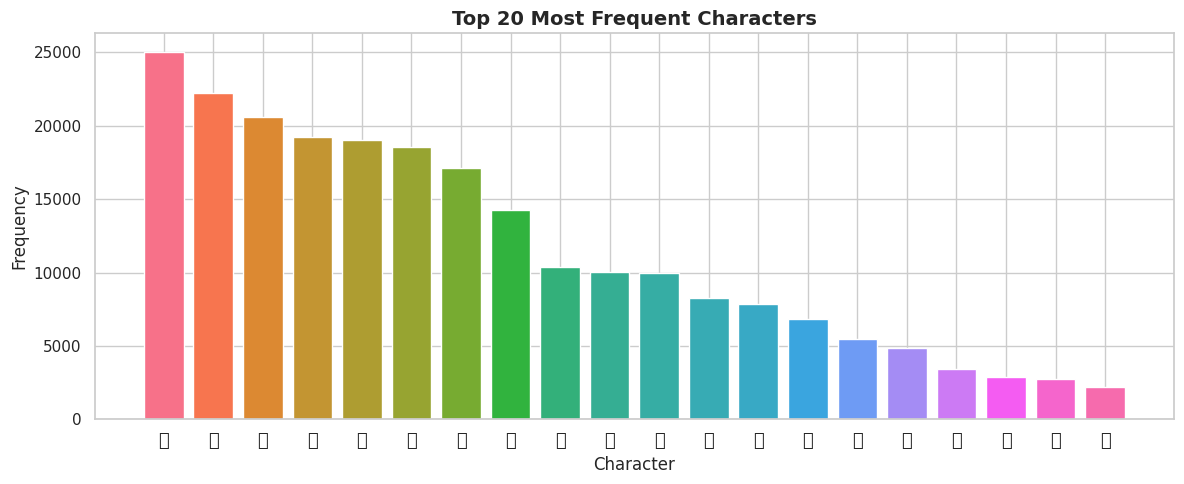

Saved: top_characters.png


In [ ]:
all_text = " ".join(df["comments"].tolist())
# Exclude spaces and punctuation for character frequency
char_freq = Counter(c for c in all_text if c.strip() and c.isalpha())
top_chars = char_freq.most_common(20)

chars, freqs = zip(*top_chars) if top_chars else ([], [])

plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(chars)), freqs, color=sns.color_palette("husl", len(chars)))
plt.xticks(range(len(chars)), chars, fontsize=13)
plt.title("Top 20 Most Frequent Characters", fontsize=14, fontweight="bold")
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("news_category_visualization/top_characters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: news_category_visualization/top_characters.png")

In [ ]:
print("=" * 55)
print("         FINAL DATASET SUMMARY")
print("=" * 55)
print(f"  Total samples          : {len(df)}")
print(f"  Unique labels          : {df['labels'].nunique()} → {sorted(df['labels'].dropna().unique().tolist())}")
print(f"  Missing comments       : {df['comments'].isnull().sum()}")
print(f"  Missing labels         : {df['labels'].isnull().sum()}")
print(f"  Avg comment length     : {df['char_count'].mean():.1f} chars")
print(f"  Avg word count         : {df['word_count'].mean():.1f} words")
print(f"  Shortest comment       : {df['char_count'].min()} chars")
print(f"  Longest comment        : {df['char_count'].max()} chars")
print("=" * 55)

print("\nSaved outputs:")
for fname in ["news_category_visualization/label_distribution.png", "news_category_visualization/text_length_distribution.png",
              "news_category_visualization/text_length_by_label.png", "news_category_visualization/top_characters.png"]:
    print(f"  • {fname}")

         FINAL DATASET SUMMARY
  Total samples          : 3327
  Unique labels          : 5 → [0, 1, 2, 3, 4]
  Missing comments       : 0
  Missing labels         : 0
  Avg comment length     : 148.0 chars
  Avg word count         : 23.4 words
  Shortest comment       : 1 chars
  Longest comment        : 1094 chars

Saved outputs:
  • label_distribution.png
  • text_length_distribution.png
  • text_length_by_label.png
  • top_characters.png
